In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFE, MutualInfoClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from itertools import combinations
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer

In [35]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('ggplot')
sns.set_palette("husl")

# Define Column Names for NSL-KDD (Standard List)
COL_NAMES = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty_level"]

In [3]:
# Load Data (Assuming data is in ../SentinelNet/data or ../data relative to notebook)
# You might need to adjust the path based on your exact folder structure
train_path = './data/KDDTrain+.txt'
test_path = './data/KDDTest+.txt'

# Try loading with error handling for paths
try:
    df_train = pd.read_csv(train_path, header=None, names=COL_NAMES)
    df_test = pd.read_csv(test_path, header=None, names=COL_NAMES)
    print(f"Training Data Shape: {df_train.head()}")
    print(f"Test Data Shape: {df_test.tail()}")
except FileNotFoundError:
    print("Files not found. Please check the paths. Trying absolute paths or checking local directory...")
    # Fallback to local directory if paths are different
    if os.path.exists('KDDTrain+.txt'):
        df_train = pd.read_csv('KDDTrain+.txt', header=None, names=COL_NAMES)
        df_test = pd.read_csv('KDDTest+.txt', header=None, names=COL_NAMES)

# Combine for initial analysis (optional, but good for understanding full global distributions)
# We will split back later to avoid data leakage.
# For rigorous preprocessing, we fit on TRAIN and transform TEST.

Training Data Shape:    duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0

In [4]:
# Mapping Dictionary
attack_mapping = {
    'normal': 'normal',
    
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    
    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    
    # R2L
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L', 'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R', 'ps': 'U2R', 'xterm': 'U2R', 'sqlattack': 'U2R'
}

# Apply mapping
df_train['attack_class'] = df_train['label'].map(lambda x: attack_mapping.get(x, 'other'))
df_test['attack_class'] = df_test['label'].map(lambda x: attack_mapping.get(x, 'other'))

print("Training Class Distribution:")
print(df_train['attack_class'].value_counts())

Training Class Distribution:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [5]:
#Defining feature Groups

categorical_features = ['protocol_type','service','flag']
binary_features = ['land','logged_in','is_host_login','is_guest_login']
#All the other numerical values

numerical_features = [col for col in COL_NAMES if col not in categorical_features + binary_features +['label','difficulty_level']]

print(f"Categorical Features: {len(categorical_features)}")
print(f"Binary Features: {len(binary_features)}")
print(f"Numerical Features: {len(numerical_features)}")

print(df_train.isnull())

Categorical Features: 3
Binary Features: 4
Numerical Features: 34
        duration  protocol_type  service   flag  src_bytes  dst_bytes   land  \
0          False          False    False  False      False      False  False   
1          False          False    False  False      False      False  False   
2          False          False    False  False      False      False  False   
3          False          False    False  False      False      False  False   
4          False          False    False  False      False      False  False   
...          ...            ...      ...    ...        ...        ...    ...   
125968     False          False    False  False      False      False  False   
125969     False          False    False  False      False      False  False   
125970     False          False    False  False      False      False  False   
125971     False          False    False  False      False      False  False   
125972     False          False    False  False      F

In [6]:
def clean_outliers_isolation_forest(df,contamination = 0.01):
    iso_df  = df[numerical_features].copy()

    clf = IsolationForest(max_samples='auto',contamination = contamination, random_state = 42)

    outliers = clf.fit_predict(iso_df)

    n_outliers = (outliers == -1).sum()
    print(f"Identifies {n_outliers} Outliers using the Isolation forest")

    return outliers
df_train['is_outlier'] = clean_outliers_isolation_forest(df_train)

Identifies 1256 Outliers using the Isolation forest


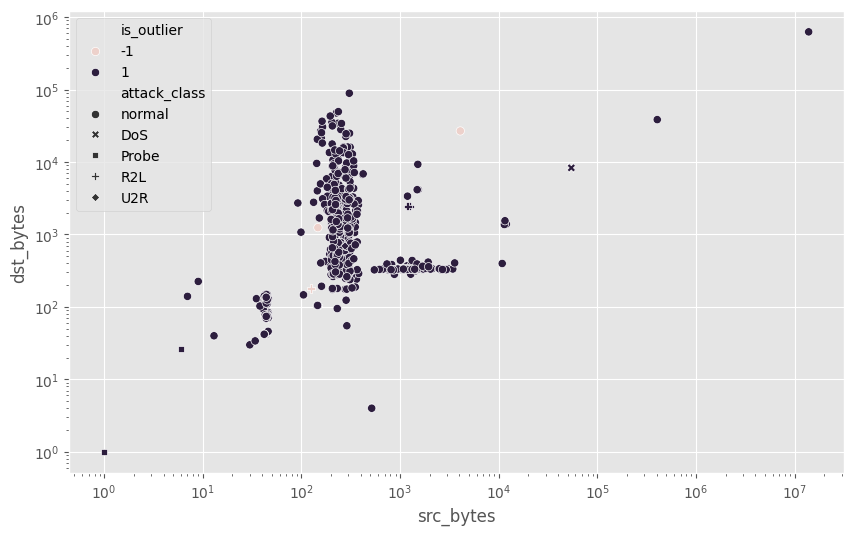

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_train[::100], x = 'src_bytes', y = 'dst_bytes', hue='is_outlier', style='attack_class')
plt.xscale('log')
plt.yscale('log')
plt.show()

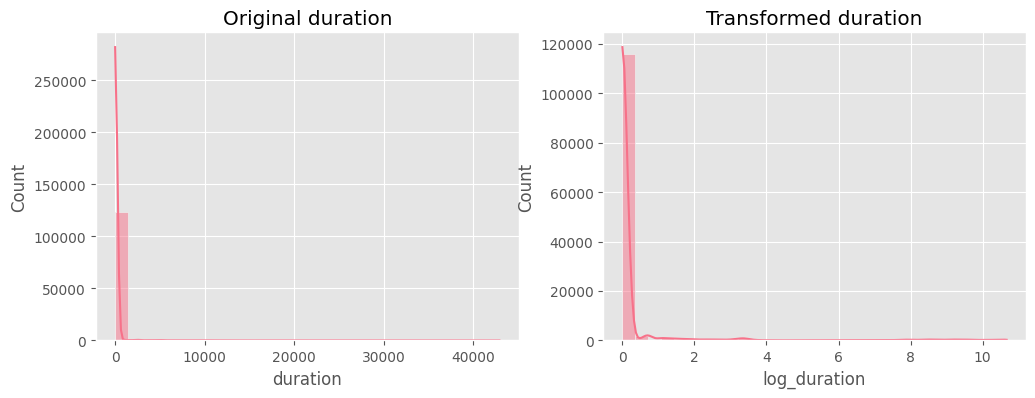

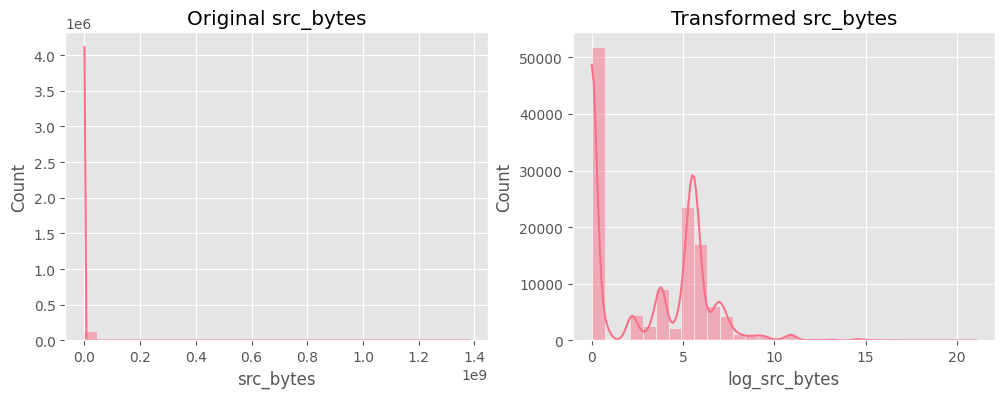

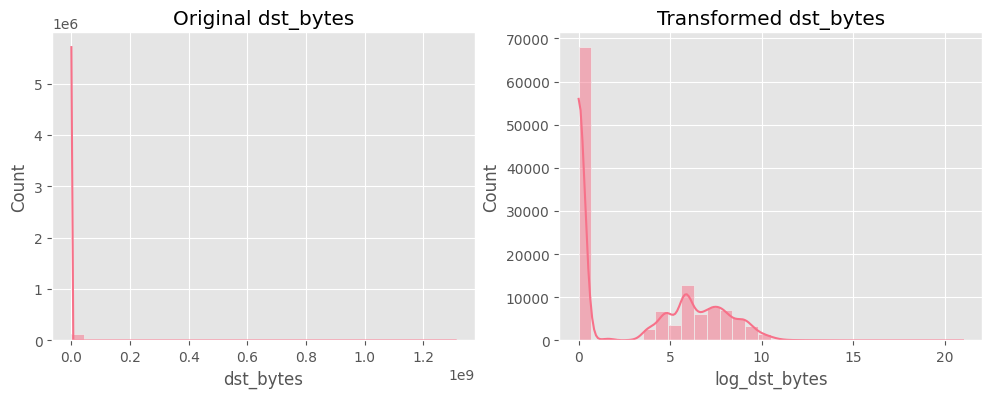

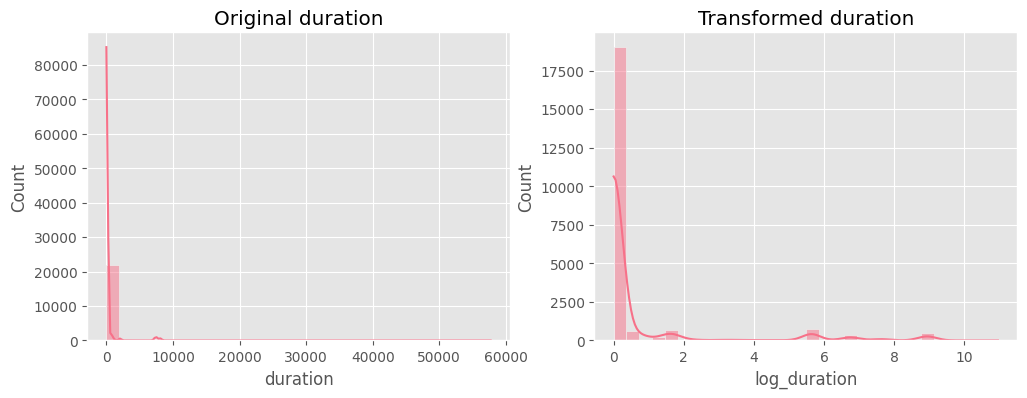

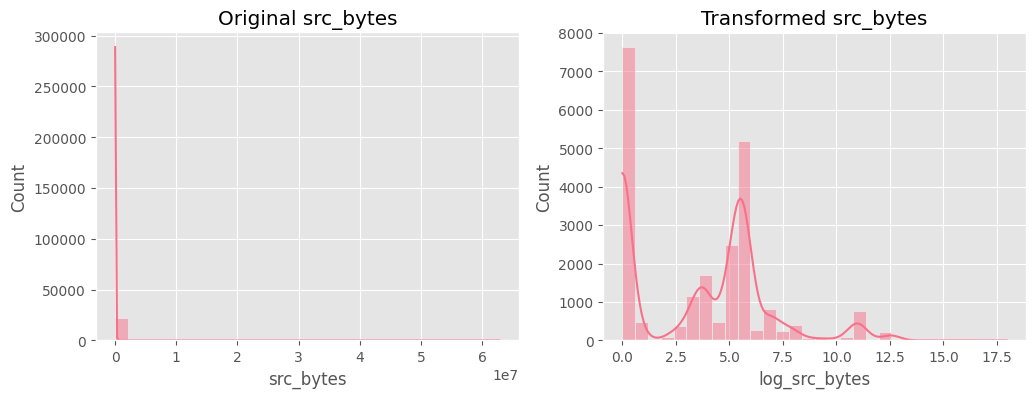

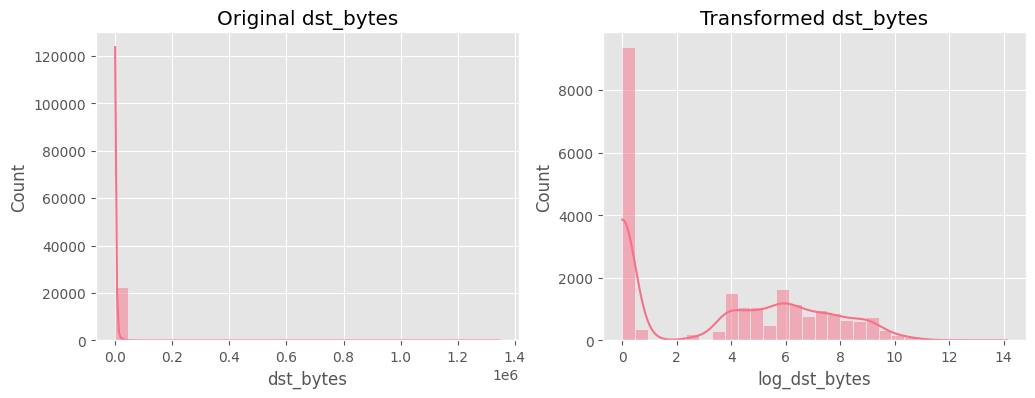

In [8]:
skewed_cols = ['duration','src_bytes','dst_bytes']

# Function for the Log1p transformation (log(x+1)) to handle the zeros

def apply_log_transform(df, cols):
    df_transform = df.copy()
    for col in cols:
        # creating a new column name
        new_col = f"log_{col}"
        # apply the logarithmic operation
        df_transform[new_col] = np.log1p(df_transform[col])

        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"Original {col}")

        plt.subplot(1,2,2)
        sns.histplot(df_transform[new_col], bins=30, kde=True)
        plt.title(f"Transformed {col}")
        plt.show()
    # return the updated dataframe (fixed variable name)
    return df_transform

# apply the transformation to both train and test sets

df_train = apply_log_transform(df_train, skewed_cols)
df_test = apply_log_transform(df_test, skewed_cols)


In [9]:
import pandas as pd

# load the separate labeled dataset (file has no extension but is CSV formatted)
# adjust the path or filename if necessary
labeled_df = pd.read_csv("labeled_CSV", header=0)
labeled_df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [10]:
import numpy as np

# work with the labeled dataset
log_df = labeled_df[['duration', 'src_bytes', 'dst_bytes']].copy()

for col in ['duration', 'src_bytes', 'dst_bytes']:
    log_df[col] = np.log1p(log_df[col])


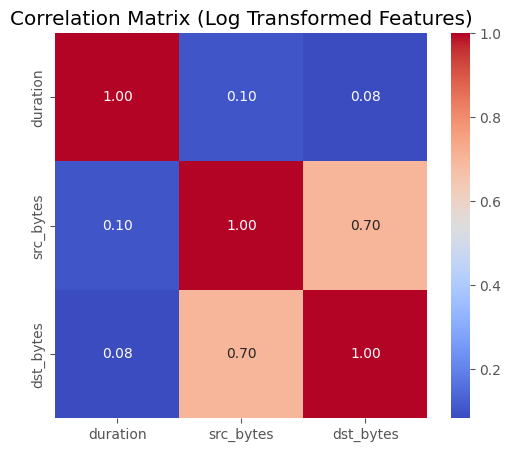

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

log_corr = log_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(log_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Log Transformed Features)")
plt.show()

In [12]:
df_train_work = df_train.copy()\ndf_test_work = df_test.copy()

SyntaxError: unexpected character after line continuation character (3861517854.py, line 1)

In [ ]:
for df in [df_train_work, df_test_work]:

    df['total_bytes'] = df['src_bytes'] + df['dst_bytes']
    df['bytes_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)

In [ ]:
def engineer_features(df):
    df_eng = df.copy()
    
    # 1. Total Bytes
    df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']
    
    # 2. Byte Ratio (Handle division by zero)
    df_eng['src_bytes_ratio'] = df_eng['src_bytes'] / (df_eng['total_bytes'] + 1e-5)
    
    # 3. Load / Packet Rate
    # If duration is 0, we assume it's a single instantaneous event (rate = count)
    df_eng['packet_rate'] = df_eng['count'] / (df_eng['duration'] + 1e-5)
    
    # 4. Title: Flow Asymmetry
    df_eng['byte_diff'] = abs(df_eng['src_bytes'] - df_eng['dst_bytes'])
    
    # 5. Flag interactions (example: is it an error flag?)
    error_flags = ['S0', 'S1', 'S2', 'S3', 'REJ']
    df_eng['is_error_flag'] = df_eng['flag'].isin(error_flags).astype(int)
    
    # 6. Critical Host Interaction
    # Interaction between 'same_srv_rate' and 'dst_host_same_srv_rate'
    df_eng['same_srv_interaction'] = df_eng['same_srv_rate'] * df_eng['dst_host_same_srv_rate']
    
    return df_eng

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

print("New Feature Set Head:")
print(df_train[['src_bytes_ratio', 'packet_rate', 'is_error_flag', 'same_srv_interaction']].head())

New Feature Set Head:
   src_bytes_ratio  packet_rate  is_error_flag  same_srv_interaction
0         1.000000     200000.0              0                 0.170
1         1.000000    1300000.0              0                 0.000
2         0.000000   12300000.0              1                 0.005
3         0.027668     500000.0              0                 1.000
4         0.321486    3000000.0              0                 1.000


In [ ]:
# second version of engineer_features (also superseded by final helper defined later)
# def engineer_features(df):
#     df_eng = df.copy()
#
#     #  Total Bytes
#     df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']
#
#     #  Byte Ratio (avoid division by zero)
#     df_eng['src_bytes_ratio'] = df_eng['src_bytes'] / (df_eng['total_bytes'] + 1)
#
#     #  Packet Rate (handle duration = 0)
#     df_eng['packet_rate'] = df_eng['count'] / (df_eng['duration'] + 1)
#
#     # Logged Duration (optional extra feature)
#     df_eng['log_duration'] = np.log1p(df_eng['duration'])
#
#     return df_eng


In [ ]:
# use the most recent version of the feature‑engineering helper on the labeled dataset

df_transformed = engineer_features(labeled_df)

df_transformed.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level,total_bytes,src_bytes_ratio,packet_rate,byte_diff,is_error_flag,same_srv_interaction
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.05,0.00,normal,20,491,1.000000,200000.0,491,0,0.170
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.00,normal,15,146,1.000000,1300000.0,146,0,0.000
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.00,0.00,neptune,19,0,0.000000,12300000.0,0,1,0.005
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.01,normal,21,8385,0.027668,500000.0,7921,0,1.000
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,normal,21,619,0.321486,3000000.0,221,0,1.000


In [ ]:
# review the column names of the labeled dataset
labeled_df.columns


Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class', 'difficulty_level'],
      dtype='object')

In [ ]:
df_train['service']


0         ftp_data
1            other
2          private
3             http
4             http
            ...   
125968     private
125969     private
125970        smtp
125971      klogin
125972    ftp_data
Name: service, Length: 125973, dtype: object

In [ ]:
import numpy as np

def engineer_features(df):
    df_eng = df.copy()

    # 1️⃣ Total Bytes
    df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']

    # 2️⃣ Source Byte Ratio (safe division)
    df_eng['src_bytes_ratio'] = df_eng['src_bytes'] / (df_eng['total_bytes'] + 1)

    # 3️⃣ Packet Rate (handle division by zero safely)
    df_eng['packet_rate'] = df_eng['count'] / (df_eng['duration'] + 1)

    # 4️⃣ Log Duration
    df_eng['log_duration'] = np.log1p(df_eng['duration'])

    return df_eng

In [ ]:
# run the final version of the feature engineering function on the labeled dataset

df_transformed = engineer_features(labeled_df)

df_transformed.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level,total_bytes,src_bytes_ratio,packet_rate,log_duration
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.00,0.00,0.05,0.00,normal,20,491,0.997967,2.0,0.0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.00,0.00,0.00,normal,15,146,0.993197,13.0,0.0
2,0,tcp,private,S0,0,0,0,0,0,0,...,1.00,1.00,0.00,0.00,neptune,19,0,0.000000,123.0,0.0
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.03,0.01,0.00,0.01,normal,21,8385,0.027665,5.0,0.0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,normal,21,619,0.320968,30.0,0.0


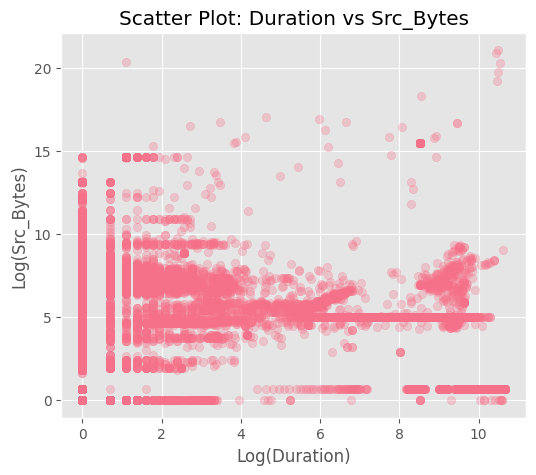

Correlation: 0.10388711355187441


In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(log_df['duration'], log_df['src_bytes'], alpha=0.3)
plt.xlabel('Log(Duration)')
plt.ylabel('Log(Src_Bytes)')
plt.title('Scatter Plot: Duration vs Src_Bytes')
plt.show()

print("Correlation:", log_df['duration'].corr(log_df['src_bytes']))

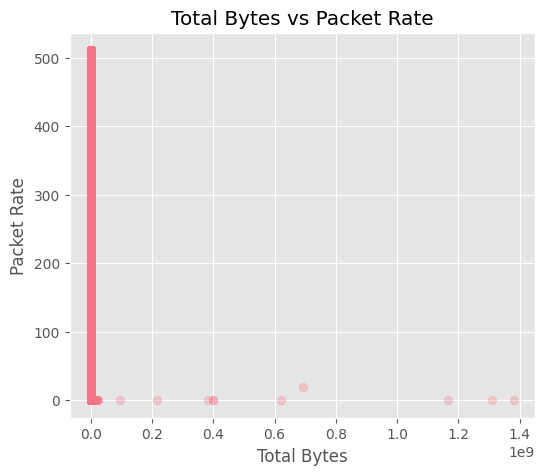

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df_transformed['total_bytes'],
            df_transformed['packet_rate'],
            alpha=0.3)

plt.xlabel("Total Bytes")
plt.ylabel("Packet Rate")
plt.title("Total Bytes vs Packet Rate")
plt.show()

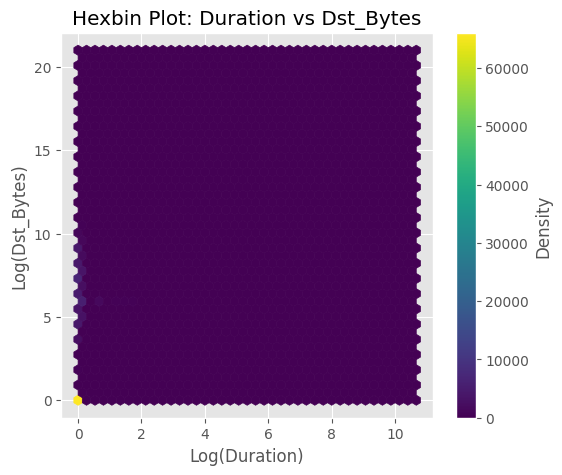

Correlation: 0.08349041551811516


In [ ]:
plt.figure(figsize=(6,5))
plt.hexbin(log_df['duration'], log_df['dst_bytes'], gridsize=40)
plt.xlabel('Log(Duration)')
plt.ylabel('Log(Dst_Bytes)')
plt.title('Hexbin Plot: Duration vs Dst_Bytes')
plt.colorbar(label='Density')
plt.show()

print("Correlation:", log_df['duration'].corr(log_df['dst_bytes']))

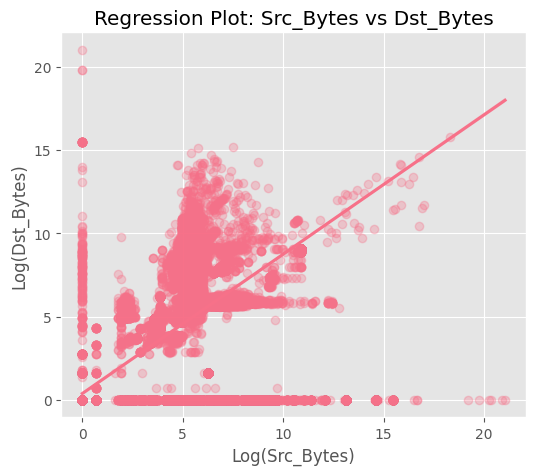

Correlation: 0.7023503920159611


In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.regplot(x=log_df['src_bytes'], y=log_df['dst_bytes'], scatter_kws={'alpha':0.3})
plt.xlabel('Log(Src_Bytes)')
plt.ylabel('Log(Dst_Bytes)')
plt.title('Regression Plot: Src_Bytes vs Dst_Bytes')
plt.show()

print("Correlation:", log_df['src_bytes'].corr(log_df['dst_bytes']))

In [ ]:
# Mapping for the target variable (Only part not inside Pipeline)
attack_mapping = {
    'normal': 'normal',
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R'
}
df_raw['attack_class'] = df_raw['label'].map(lambda x: attack_mapping.get(x, 'other'))

# 1. Extract Target
le = LabelEncoder()
y_master = le.fit_transform(df_raw['attack_class'])

# 2. Extract Features & Transform
X_raw = df_raw.drop(columns=['label', 'attack_class', 'difficulty_level'])
X_signal = prep_engine.transform(X_raw)

print(f"--- Connection Architecture ---")
print(f"Pre-Selection Features: {X_raw.shape[1]}")
print(f"Post-Selection Signal:  {X_signal.shape[1]}")

NameError: name 'df_raw' is not defined

In [ ]:
ohe = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
cols_to_encode = ['protocol_type','flag']

#Fit and Train

ohe_train = pd.DataFrame(ohe.fit_transform(df_train[cols_to_encode]))
ohe_train.columns = ohe.get_feature_names_out(cols_to_encode)
ohe_train.index = df_train.index
# ohe_train.index

#Transform Test

ohe_test = pd.DataFrame(ohe.transform(df_test[cols_to_encode]))
ohe_test.columns = ohe.get_feature_names_out(cols_to_encode)
ohe_test.index = df_test.index

service_freq = df_train['service'].value_counts(normalize = True)
df_train['service_freq'] = df_train['service'].map(service_freq)
df_test['service_freq'] = df_test['service'].map(service_freq).fillna(0)

df_train_encode = pd.concat([df_train,ohe_train],axis = 1)
df_test_encode = pd.concat([df_test,ohe_test],axis = 1)

df_train_encode.columns
# df_train_encode

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'attack_class',
       'is_outlier', 'log_duration', 'log_src_bytes', 'log_dst_bytes',
       'total_bytes', 'src_bytes_ratio', 'packet_rate', 'byte_dif

In [ ]:
print(df_train_encode.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'attack_class',
       'is_outlier', 'log_duration', 'log_src_bytes', 'log_dst_bytes',
       'total_bytes', 'src_bytes_ratio', 'packet_rate', 'byte_dif

In [ ]:
df_test_encode

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,tcp,private,REJ,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22540,0,tcp,http,SF,317,938,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df_train_encode.drop(columns=['protocol_type','flag','service'],inplace = True)
df_test_encode.drop(columns=['protocol_type','flag','service'],inplace = True)

In [ ]:
print(df_train_encode.shape)

df_test_encode

(125973, 66)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,12983,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,20,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,0,15,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,794,333,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22540,0,317,938,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22541,0,54540,8314,0,0,0,2,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22542,0,42,42,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df_train_encode

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,146,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,232,8153,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,199,420,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
125969,8,105,145,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125970,0,2231,384,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125971,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import numpy as np

corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

print("Dropped features:", to_drop)

X = X.drop(columns=to_drop)

In [ ]:
#Co-relation Filter

corr_matrix = df_train_encode.select_dtypes(include=[np.number]).corr().abs()
#Upper Triangle of teh co-realtion matrix

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))

#find features with corelation greater then 0.95
to_drop = [column for column in upper.columns if any (upper[column]>0.95)]
print(f"Features to drop due to high corelation (>0.95): {to_drop}")

#Drop them

df_train_reduce = df_train_encode.drop(columns=to_drop)
df_test_reduce = df_test_encode.drop(columns= to_drop)
try:
    cols_dropped_from_test = [c for c in top_drop if c in df_test_encode.columns]
    df_test_reduce = df_test_encode.drop(columns= cols_dropped_from_test)
except:
    pass
print(f"Reduce Shape: {df_train_reduce.shape}")

Features to drop due to high corelation (>0.95): ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction', 'flag_S0']
Reduce Shape: (125973, 56)


In [ ]:
d= df_train_encode[to_drop]
d.iloc[:10]

,num_root,srv_serror_rate,srv_rerror_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_srv_rerror_rate,packet_rate,byte_diff,same_srv_interaction,flag_S0
0,0,0.0,0.0,0.00,0.00,0.00,200000.0,491,0.1700,0.0
1,0,0.0,0.0,0.00,0.00,0.00,1300000.0,146,0.0000,0.0
2,0,1.0,0.0,1.00,1.00,0.00,12300000.0,0,0.0050,1.0
3,0,0.2,0.0,0.03,0.01,0.01,500000.0,7921,1.0000,0.0
4,0,0.0,0.0,0.00,0.00,0.00,3000000.0,221,1.0000,0.0
5,0,0.0,1.0,0.00,0.00,1.00,12100000.0,0,0.0112,0.0
6,0,1.0,0.0,1.00,1.00,0.00,16600000.0,0,0.0020,1.0
7,0,1.0,0.0,1.00,1.00,0.00,11700000.0,0,0.0084,1.0
8,0,1.0,0.0,1.00,1.00,0.00,27000000.0,0,0.0081,1.0
9,0,1.0,0.0,1.00,1.00,0.00,13300000.0,0,0.0030,1.0


In [ ]:
# Select label columns correctly
label_cols = ['label', 'attack_class', 'difficulty_level']
label = df_train_encode[[c for c in label_cols if c in df_train_encode.columns]]

# Correlation Filter
corr_matrix = df_train_encode.select_dtypes(include=[np.number]).corr().abs()

# Upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"Features to drop due to high correlation (>0.95): {to_drop}")

# Drop highly correlated features from train and test sets
df_train_reduce = df_train_encode.drop(columns=to_drop)

# Correct completed last line
df_test_reduce = df_test_encode.drop(columns=to_drop, errors='ignore')

print(f"Reduced Train Shape: {df_train_reduce.shape}")
print(f"Reduced Test Shape: {df_test_reduce.shape}")

Features to drop due to high correlation (>0.95): ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction', 'flag_S0']
Reduced Train Shape: (125973, 56)
Reduced Test Shape: (22544, 55)


In [ ]:
# ==============================
# Encode categorical features
# ==============================

# Copy datasets
df_train_encode = df_train.copy()
df_test_encode = df_test.copy()

# Find categorical columns
cat_cols = df_train_encode.select_dtypes(include=['object']).columns

# Apply Label Encoding
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()

    # Fit on combined data to avoid unseen labels in test
    combined = pd.concat([df_train_encode[col], df_test_encode[col]], axis=0)

    le.fit(combined)

    df_train_encode[col] = le.transform(df_train_encode[col])
    df_test_encode[col] = le.transform(df_test_encode[col])

    le_dict[col] = le

print("Encoding completed ")

Encoding completed 


In [ ]:
# Select label columns correctly
label_cols = ['label', 'attack_class', 'difficulty_level']

label = df_train_encode[
    [c for c in label_cols if c in df_train_encode.columns]
]

# Correlation Filter
corr_matrix = df_train_encode.select_dtypes(include=[np.number]).corr().abs()

# Upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Features with correlation > 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Features to drop due to high correlation (>0.95): {to_drop}")

# Drop features
df_train_reduce = df_train_encode.drop(columns=to_drop)
df_test_reduce = df_test_encode.drop(columns=to_drop, errors='ignore')

print(f"Reduced Train Shape: {df_train_reduce.shape}")
print(f"Reduced Test Shape: {df_test_reduce.shape}")

Features to drop due to high correlation (>0.95): ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction']
Reduced Train Shape: (125973, 46)
Reduced Test Shape: (22544, 45)


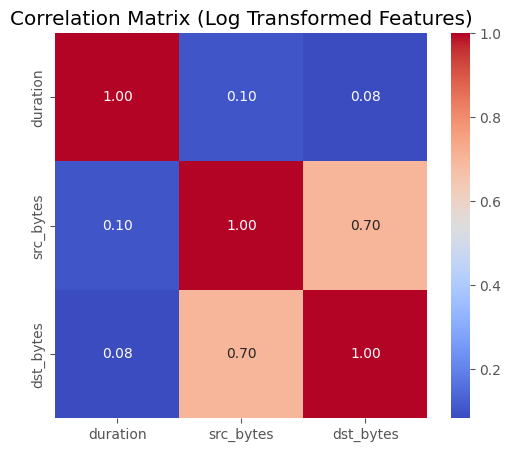

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(log_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Log Transformed Features)")
plt.show()

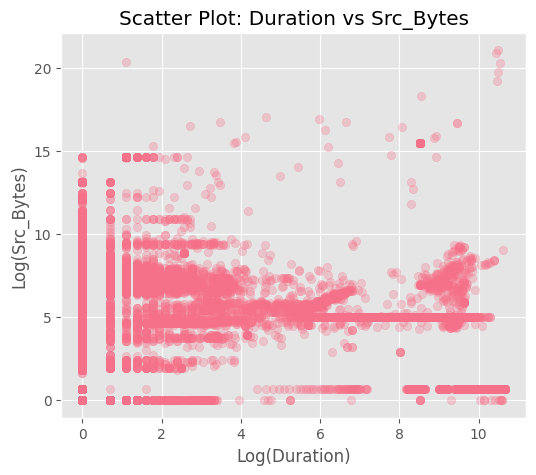

Correlation: 0.10388711355187441


In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(log_df['duration'], log_df['src_bytes'], alpha=0.3)
plt.xlabel('Log(Duration)')
plt.ylabel('Log(Src_Bytes)')
plt.title('Scatter Plot: Duration vs Src_Bytes')
plt.show()

print("Correlation:", log_df['duration'].corr(log_df['src_bytes']))

In [ ]:
import numpy as np
import pandas as pd
#Load dataset
train_df = pd.read_csv("labeled_CSV")


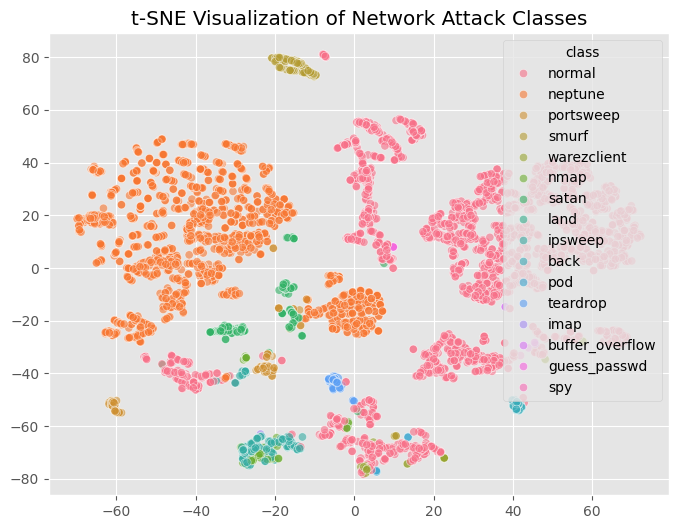

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Load dataset
df_train = pd.read_csv("log_transformed_train.csv")

# Convert categorical columns to numeric
categorical_cols = ['protocol_type', 'service', 'flag']
df_train = pd.get_dummies(df_train, columns=categorical_cols)

# Create feature matrix and labels
X_train_fs = df_train.drop(columns=['class'], errors='ignore')
y_train = df_train['class']

# Sample for faster t-SNE
sample_size = 5000 if len(X_train_fs) > 5000 else len(X_train_fs)

X_sample = X_train_fs.sample(sample_size, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_tsne = tsne.fit_transform(X_sample)

# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_sample, alpha=0.6)

plt.title("t-SNE Visualization of Network Attack Classes")
plt.show()

In [ ]:
# Select only numeric columns
numeric_cols = train_df.select_dtypes(include=np.number).columns

# Create copy
log_train_df = train_df.copy()

# Apply log(1 + x) transformation
for col in numeric_cols:
    log_train_df[col] = np.log1p(log_train_df[col])
    log_train_df.to_csv("log_transformed_train.csv", index=False)
print("Log-transformed dataset saved successfully.")

Log-transformed dataset saved successfully.


In [ ]:
# Create copy
log_train_df = train_df.copy()

# Apply log(1 + x) transformation
for col in numeric_cols:
    log_train_df[col] = np.log1p(log_train_df[col])

In [ ]:
log_train_df.to_csv("log_transformed_train.csv", index=False)

print("Log-transformed dataset saved successfully.")

Log-transformed dataset saved successfully.


In [ ]:
print(df_train_reduce.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_file_creations', 'num_shells', 'num_access_files',
       'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_rerror_rate', 'label',
       'difficulty_level', 'attack_class', 'is_outlier', 'log_duration',
       'log_src_bytes', 'log_dst_bytes', 'total_bytes', 'src_bytes_ratio',
       'is_error_flag', 'service_freq'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

NameError: name 'df' is not defined

NameError: name 'y_train' is not defined

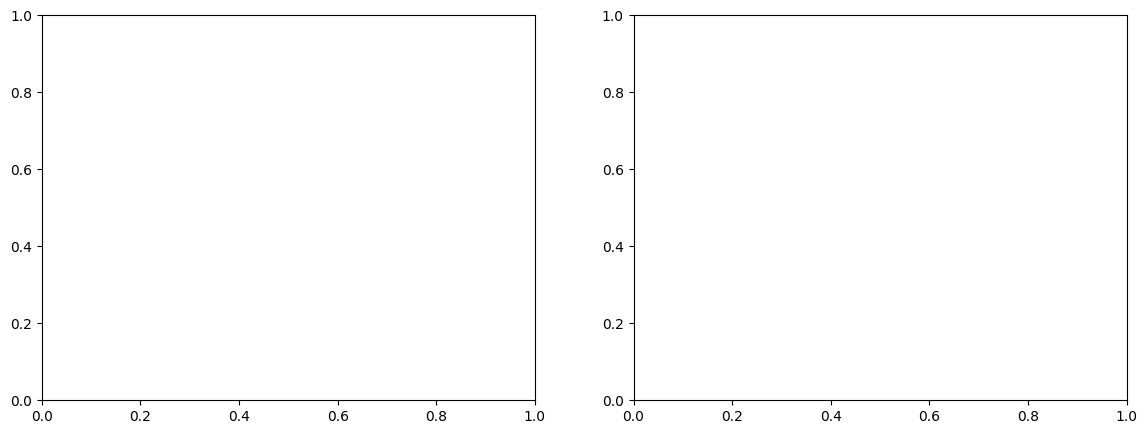

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Side by side comparison — Before vs After SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    x=pd.Series(y_train).map(dict(enumerate(le.classes_))),
    ax=axes[0], palette="husl"
)
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Attack Class")
axes[0].set_ylabel("Count")

sns.countplot(
    x=pd.Series(y_resampled).map(dict(enumerate(le.classes_))),
    ax=axes[1], palette="husl"
)
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Attack Class")
axes[1].set_ylabel("Count")

plt.suptitle("Class Imbalance — Before vs After SMOTE", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

# Target column
target_col = 'attack_class'

# Features and target
X = df_train.drop(columns=['label', 'attack_class', 'difficulty_level'], errors='ignore')
y = df_train[target_col]

# Check class distribution before SMOTE
print("Before SMOTE:")
print(y.value_counts())

# Ensure no missing values
X = X.fillna(0)

# Apply SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(y_resampled.value_counts())

y_resampled

Before SMOTE:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


ValueError: could not convert string to float: 'tcp'

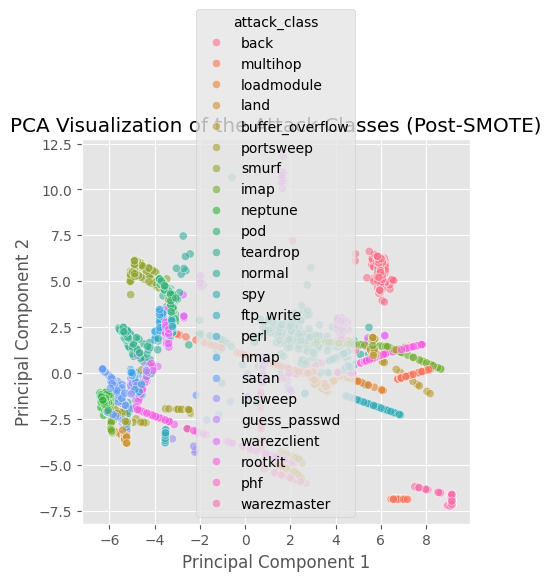

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# Load dataset
df_train_reduce = pd.read_csv("log_transformed_train.csv")

# Create attack_class
df_train_reduce['attack_class'] = df_train_reduce['class']

# Encode categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']
df_train_reduce = pd.get_dummies(df_train_reduce, columns=categorical_cols)

# Features and target
X = df_train_reduce.drop(columns=['class','attack_class','difficulty_level'], errors='ignore')
y = df_train_reduce['attack_class']

# Fill missing values
X = X.fillna(0)

# Apply SMOTE
smote = SMOTE(k_neighbors=1, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# PCA
pca = PCA(n_components=2)

sample_X = X_resampled.sample(5000, random_state=42)
sample_y = y_resampled.loc[sample_X.index]

x_pca = pca.fit_transform(sample_X)

# Plot
plt.figure(figsize=(5,5))

sns.scatterplot(
    x=x_pca[:,0],
    y=x_pca[:,1],
    hue=sample_y,
    alpha=0.6
)

plt.title("PCA Visualization of the Attack Classes (Post-SMOTE)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
print(y.value_counts())

attack_class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

for name, model in models.items():

    preds = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))


Random Forest
Accuracy: 0.9990871204604088
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195


Logistic Regression
Accuracy: 0.8746973605874181
              precision    recall  f1-score   support

           0       0.88      0.89      0.88     13469
           1       0.87      0.86      0.86     11726

    accuracy                           0.87     25195
   macro avg       0.87      0.87      0.87     25195
weighted avg       0.87      0.87      0.87     25195


SVM
Accuracy: 0.5351855526890256
              precision    recall  f1-score   support

           0       0.53      1.00      0.70     13469
           1       0.86      0.00      0.00     11726

    accuracy                           0.54     25195


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df_train = pd.read_csv("log_transformed_train.csv")

skewed_cols = ['duration', 'src_bytes', 'dst_bytes']

# Skewness before transformation
skewness_before = df_train[skewed_cols].skew()

# Apply log transformation
log_cols = {}
for col in skewed_cols:
    log_cols[f'log_{col}'] = np.log1p(df_train[col])

# Create dataframe
log_df = pd.DataFrame(log_cols)

# Skewness after transformation
skewness_after = log_df.skew()

# Summary table
skewness_summary = pd.DataFrame({
    'feature': skewed_cols,
    'skewness_original': skewness_before.values,
    'skewness_log1p': skewness_after.values
})

print("Skewness Summary:")
print(skewness_summary.to_string(index=False))

Skewness Summary:
  feature  skewness_original  skewness_log1p
 duration           5.338451        4.146247
src_bytes           0.310643       -0.231897
dst_bytes           0.493738        0.232884


In [ ]:
#Correlation between skewed columns (original & log-transformed) ──
combined_for_corr = pd.concat([df_train[skewed_cols], log_df], axis=1)
corr_matrix       = combined_for_corr.corr()

print("\nCorrelation Matrix (original + log-transformed):")
print(corr_matrix.round(4))

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation — Skewed Columns (Original vs Log-Transformed)')
plt.tight_layout()
plt.show()


Correlation Matrix (original + log-transformed):
               duration  src_bytes  dst_bytes  log_duration  log_src_bytes  \
duration         1.0000     0.1039     0.0835        0.9625         0.1081   
src_bytes        0.1039     1.0000     0.7024        0.1606         0.9691   
dst_bytes        0.0835     0.7024     1.0000        0.1247         0.7442   
log_duration     0.9625     0.1606     0.1247        1.0000         0.1536   
log_src_bytes    0.1081     0.9691     0.7442        0.1536         1.0000   
log_dst_bytes    0.0974     0.7158     0.9824        0.1434         0.7691   

               log_dst_bytes  
duration              0.0974  
src_bytes             0.7158  
dst_bytes             0.9824  
log_duration          0.1434  
log_src_bytes         0.7691  
log_dst_bytes         1.0000  


NameError: name 'plt' is not defined

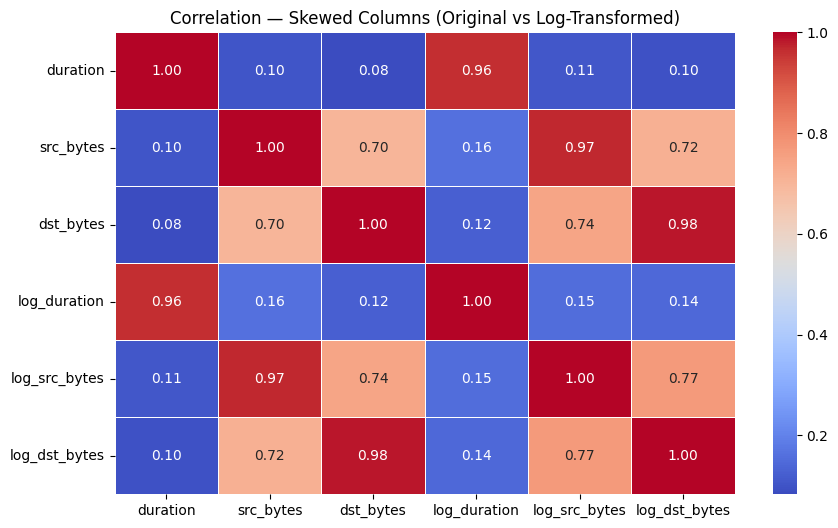

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation — Skewed Columns (Original vs Log-Transformed)")
plt.show()

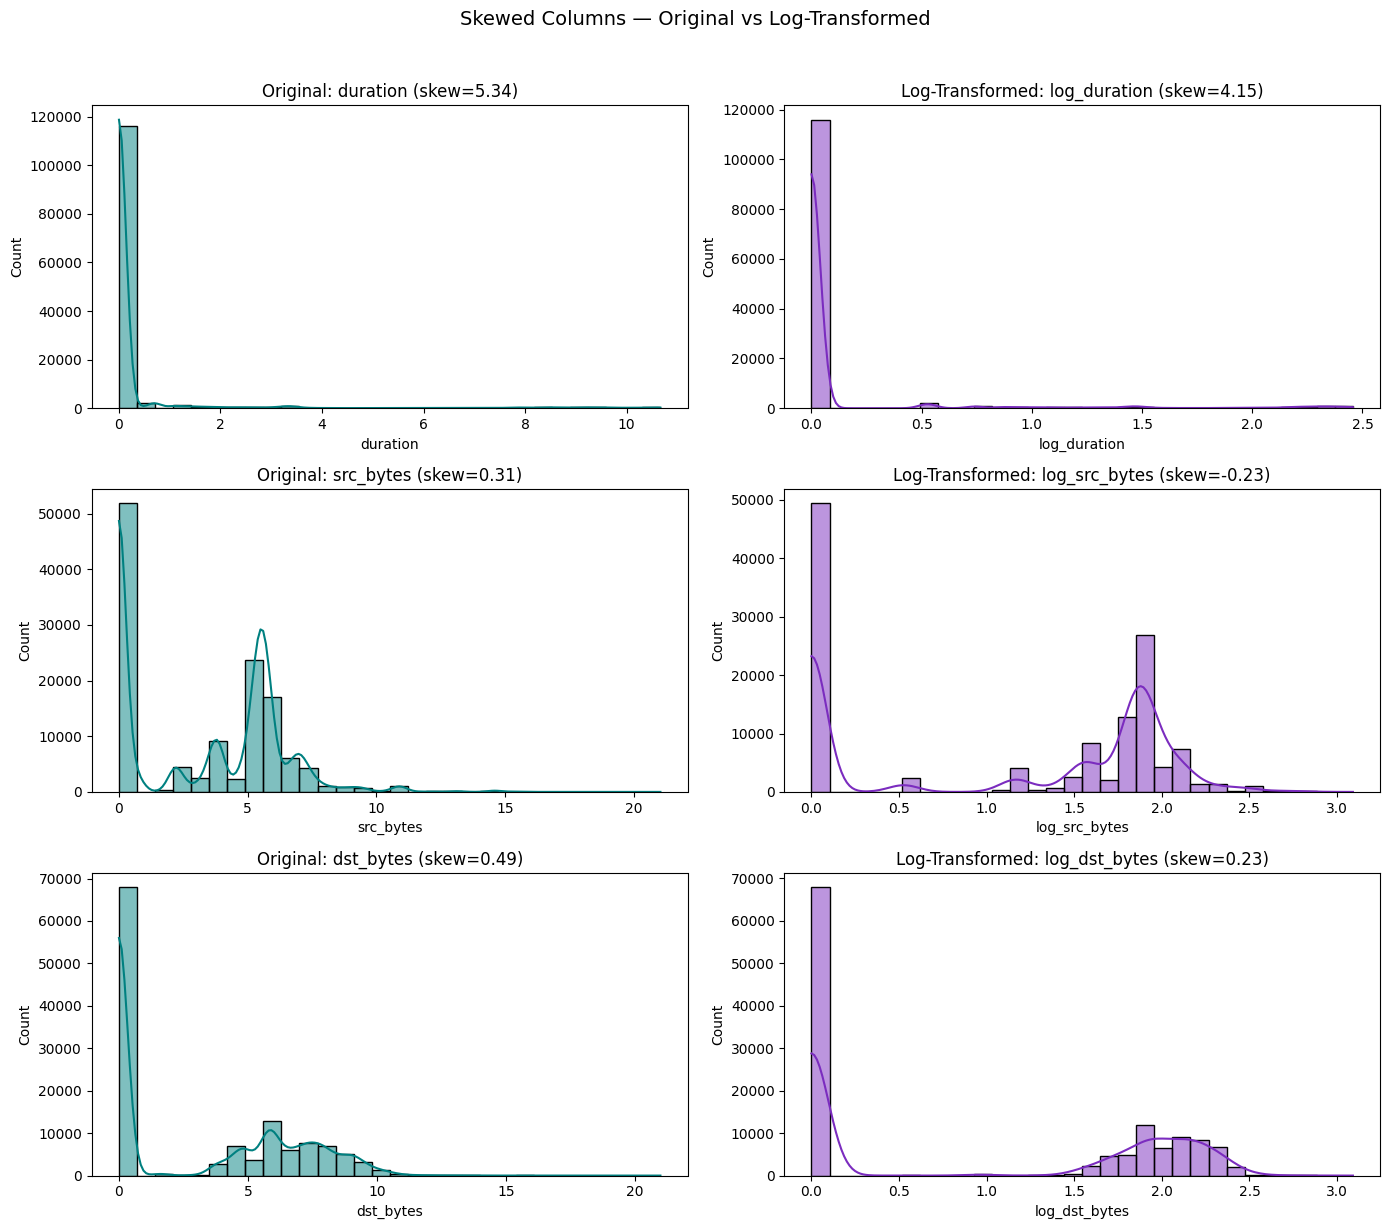

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Columns with skewness
skewed_cols = ['duration', 'src_bytes', 'dst_bytes']

# Skewness before transformation
skewness_before = df_train[skewed_cols].skew()

# Log transform
log_df = {}
for col in skewed_cols:
    log_df[f'log_{col}'] = np.log1p(df_train[col])

log_df = pd.DataFrame(log_df)

# Skewness after transformation
skewness_after = log_df.skew()

# Plot distributions
fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(14, 4 * len(skewed_cols)))

for i, col in enumerate(skewed_cols):

    # Original distribution
    sns.histplot(
        df_train[col],
        bins=30,
        kde=True,
        ax=axes[i][0],
        color="#008080"   # teal
    )

    axes[i][0].set_title(
        f"Original: {col} (skew={skewness_before[col]:.2f})"
    )

    # Log transformed distribution
    sns.histplot(
        log_df[f'log_{col}'],
        bins=30,
        kde=True,
        ax=axes[i][1],
        color="#7B2CBF"   # purple
    )

    axes[i][1].set_title(
        f"Log-Transformed: log_{col} (skew={skewness_after[f'log_{col}']:.2f})"
    )

plt.suptitle("Skewed Columns — Original vs Log-Transformed", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def engineer_features(df):
    df_eng = df.copy()

    # Total bytes transferred
    df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']

    # Ratio of source bytes
    df_eng['src_bytes_ratio'] = df_eng['src_bytes'] / (df_eng['total_bytes'] + 1e-5)

    # Packets per second
    df_eng['packet_rate'] = df_eng['count'] / (df_eng['duration'] + 1e-5)

    # Difference between source and destination bytes
    df_eng['byte_diff'] = abs(df_eng['src_bytes'] - df_eng['dst_bytes'])

    # Error flag indicator
    error_flags = ['S0', 'S1', 'S2', 'S3', 'REJ']
    df_eng['is_error_flag'] = df_eng['flag'].isin(error_flags).astype(int)

    # Service interaction feature
    df_eng['same_srv_interaction'] = df_eng['same_srv_rate'] * df_eng['dst_host_same_srv_rate']

    return df_eng


# Apply feature engineering directly to dataset
df_train = engineer_features(df_train)

print("New Feature Set Head:")
print(df_train[['src_bytes_ratio', 'packet_rate', 'is_error_flag', 'same_srv_interaction']].head())

New Feature Set Head:
   src_bytes_ratio    packet_rate  is_error_flag  same_srv_interaction
0         0.999998  109861.228867              0              0.108827
1         0.999998  263905.732962              0              0.000000
2         0.000000  482028.156561              1              0.004650
3         0.377044  179175.946923              0              0.480453
4         0.467184  343398.720449              0              0.480453


In [ ]:
import numpy as np

# Create feature matrix (remove target column if present)
X_fs = df_train.drop(columns=['class'], errors='ignore')

# Compute correlation matrix
corr_matrix_fs = X_fs.corr().abs()

# Get upper triangle of correlation matrix
upper_tri = corr_matrix_fs.where(
    np.triu(np.ones(corr_matrix_fs.shape), k=1).astype(bool)
)

# Find columns with correlation greater than 0.95
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]

# Remove highly correlated features
X_fs = X_fs.drop(columns=high_corr_cols)

print("Features removed (correlation > 0.95):", len(high_corr_cols))
print("Removed features:", high_corr_cols)
print("Features remaining:", X_fs.shape[1])

ValueError: could not convert string to float: 'tcp'

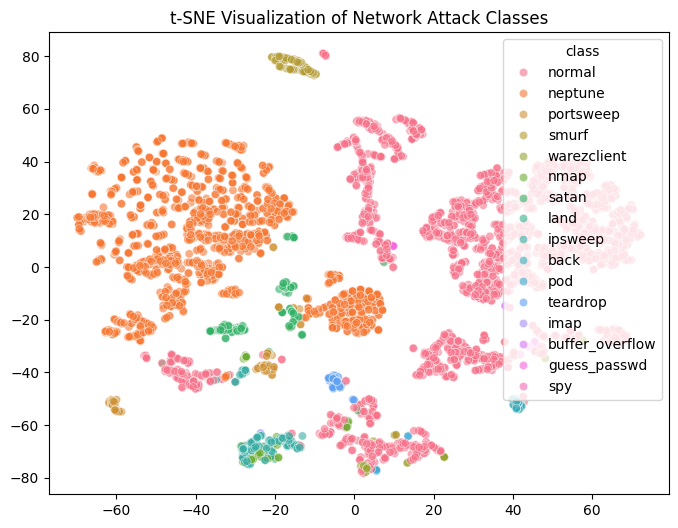

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Load dataset
df_train = pd.read_csv("log_transformed_train.csv")

# Convert categorical columns to numeric
categorical_cols = ['protocol_type', 'service', 'flag']
df_train = pd.get_dummies(df_train, columns=categorical_cols)

# Create feature matrix and labels
X_train_fs = df_train.drop(columns=['class'], errors='ignore')
y_train = df_train['class']

# Sample for faster t-SNE
sample_size = 5000 if len(X_train_fs) > 5000 else len(X_train_fs)

X_sample = X_train_fs.sample(sample_size, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_tsne = tsne.fit_transform(X_sample)

# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_sample, alpha=0.6)

plt.title("t-SNE Visualization of Network Attack Classes")
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("log_transformed_train.csv")

In [ ]:
y = df["class"]

In [ ]:
X = df.select_dtypes(include=["int64","float64"])
X = X.drop("difficulty_level", axis=1)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("feature_select", SelectKBest(score_func=f_classif, k=20)),
    ("model", RandomForestClassifier())
])

In [ ]:
pipeline.fit(X, y)

c:\Users\Sowbharanika\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [16] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Sowbharanika\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [ ]:
pred = pipeline.predict(X)

print(pred[:10])

['normal' 'normal' 'neptune' 'normal' 'normal' 'neptune' 'neptune'
 'neptune' 'neptune' 'neptune']


In [ ]:
predictions = pipeline.predict(X)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9998412358203742


In [ ]:
import pandas as pd

df = pd.read_csv("log_transformed_train.csv")

# target
y = df["class"]

# numeric features
X = df.select_dtypes(include=["int64","float64"])
X = X.drop("difficulty_level", axis=1)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("feature_select", SelectKBest(score_func=f_classif, k=20)),
    ("model", RandomForestClassifier())
])

pipeline.fit(X, y)

predictions = pipeline.predict(X)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y, predictions))

c:\Users\Sowbharanika\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [16] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Sowbharanika\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Accuracy: 0.9998412358203742


In [ ]:
import pandas as pd

df = pd.read_csv("log_transformed_train.csv")

In [ ]:
y = df["class"]

In [ ]:
X = df.drop(["class","difficulty_level"], axis=1)

numeric_cols = X.select_dtypes(include=["int64","float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier())
])

In [ ]:
pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [ ]:
pred = pipeline.predict(X)
print(pred[:10])

['normal' 'normal' 'neptune' 'normal' 'normal' 'neptune' 'neptune'
 'neptune' 'neptune' 'neptune']


In [ ]:
print("Total features used:", X.shape[1])

Total features used: 41


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
import joblib

joblib.dump(numeric_pipeline, "preprocessing_pipeline.joblib")

['preprocessing_pipeline.joblib']

In [ ]:
import joblib

preprocessor = joblib.load("preprocessing_pipeline.joblib")

In [ ]:
SimpleImputer(strategy="median")
StandardScaler()

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
import pandas as pd

df = pd.read_csv("log_transformed_train.csv")

# target
y = df["class"]

# remove columns not needed
X = df.drop(["class", "difficulty_level", "protocol_type", "service", "flag"], axis=1)

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from tkinter import Tk
from tkinter.filedialog import askopenfilename


# Select dataset file
Tk().withdraw()
file_path = askopenfilename(title="Select KDDTrain+.csv file")

df_train = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Dataset shape:", df_train.shape)


# Column groups
categorical_cols = ['protocol_type', 'service', 'flag']

binary_cols = [
    'land',
    'logged_in',
    'is_host_login',
    'is_guest_login'
]

ignore_cols = [
    'label',
    'difficulty_level',
    'attack_class'
]


# Detect numerical columns automatically
numerical_cols = [
    col for col in df_train.columns
    if col not in categorical_cols + binary_cols + ignore_cols
]


# Feature engineering
def add_features(data):

    df = data.copy()

    # packet rate
    df["packet_rate"] = df["count"] / (df["duration"] + 1e-5)

    # byte ratio
    total_bytes = df["src_bytes"] + df["dst_bytes"]
    df["src_bytes_ratio"] = df["src_bytes"] / (total_bytes + 1e-5)

    # service interaction
    df["srv_interaction"] = df["same_srv_rate"] * df["dst_host_same_srv_rate"]

    return df


# Numerical preprocessing
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scale", RobustScaler())
])


# Categorical preprocessing
cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])


# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols),
    ("bin", SimpleImputer(strategy="most_frequent"), binary_cols)
])


# Full ML pipeline
model_pipeline = ImbPipeline([

    ("feature_engineering",
     FunctionTransformer(add_features, validate=False)),

    ("preprocessing", preprocessor),

    ("smote", SMOTE(random_state=42)),

    ("feature_selection",
     SelectFromModel(
         RandomForestClassifier(
             n_estimators=50,
             random_state=42,
             n_jobs=-1
         )
     )),

    ("classifier",
     RandomForestClassifier(
         n_estimators=200,
         random_state=42,
         n_jobs=-1
     ))
])


# Prepare training data
X = df_train[numerical_cols + categorical_cols + binary_cols]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_train["attack_class"])


# Train model
print("\nTraining model...")

model_pipeline.fit(X, y)

print("Training completed successfully")


# Save model
save_folder = "models"
os.makedirs(save_folder, exist_ok=True)

model_path = os.path.join(save_folder, "ids_model_pipeline.joblib")

joblib.dump(model_pipeline, model_path)

print("\nModel saved at:", model_path)

In [8]:
from sklearn.ensemble import IsolationForest
import pandas as pd

print("\n### ANALYZING NORMALCY BASELINES ###")

iso = IsolationForest(contamination=0.03, random_state=42)

# use processed features
iso.fit(X_processed)

iso_score = iso.decision_function(X_processed)
iso_pred = iso.predict(X_processed)

analysis_df = pd.DataFrame({
    "attack_class": y_master,
    "iso_score": iso_score,
    "iso_pred": iso_pred
})

analysis_df["is_anomaly"] = analysis_df["iso_pred"].map({1: 0, -1: 1})

print("Isolation Forest completed.")
print(analysis_df.head())


### ANALYZING NORMALCY BASELINES ###


NameError: name 'X_processed' is not defined

In [3]:
print("len(y_resampled):", len(y_resampled))
print("len(iso_score):", len(iso_score))
print("len(iso_pred):", len(iso_pred))
print("len(X_signal):", len(X_signal))

NameError: name 'y_resampled' is not defined

In [1]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.violinplot(
    x="attack_class",
    y="iso_score",
    data=analysis_df,
    palette="coolwarm"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Isolation Scores by Attack Class")
plt.xlabel("Attack Class")
plt.ylabel("Isolation Score")


plt.subplot(1, 2, 2)
sns.countplot(
    x="attack_class",
    hue="is_anomaly",
    data=analysis_df,
    palette=["#4CAF50", "#FF6B6B"]   # green & red
)

plt.title("Anomaly Labels vs Attack Categories")
plt.yscale("log")
plt.xlabel("Attack Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

NameError: name 'X_resampled' is not defined

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [4]:
import pandas as pd

# load dataset
df_raw = pd.read_csv("log_transformed_train.csv")

print("Dataset loaded:", df_raw.shape)

Dataset loaded: (125973, 43)


ValueError: Could not interpret value `attack_class` for `x`. An entry with this name does not appear in `data`.

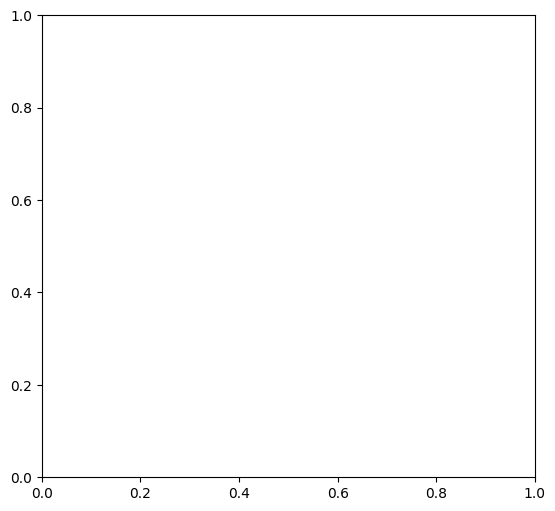

In [8]:
# import libraries if not already imported
import matplotlib.pyplot as plt
import seaborn as sns

# create figure
plt.figure(figsize=(14,6))


# box plot for isolation scores
plt.subplot(1,2,1)

sns.boxplot(
    x='attack_class',
    y='iso_score',
    data=df_raw
)

plt.axhline(0, color='red', linestyle='--')

plt.title("Isolation Forest Scores by Attack Type")
plt.xlabel("Attack Class")
plt.ylabel("Isolation Score")


# stacked bar chart for anomaly count
plt.subplot(1,2,2)

anomaly_counts = pd.crosstab(
    df_raw['attack_class'],
    df_raw['is_anomaly']
)

anomaly_counts.plot(
    kind='bar',
    stacked=True,
    ax=plt.gca()
)

plt.title("Detected Anomalies per Attack Category")
plt.xlabel("Attack Class")
plt.ylabel("Count")


# adjust layout and show
plt.tight_layout()
plt.show()